# Análisis Geoespacial

Daniel Núñez Vargas

In [1]:
# Librerias base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import calendar

# Para el análisis descriptivo inicial de contraste de asociación  
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway
from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, classification_report
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Librerias que permiten trabajar con datos geoespaciales
import geopandas as gpd
from libpysal import weights
import esda
import spreg
from splot import esda as esdaplot
from splot.esda import plot_moran

# Librería para hacer la tramificación, agrupación y transformación WOE
from optbinning import Scorecard, BinningProcess, OptimalBinning
from optbinning.scorecard import plot_auc_roc, plot_cap, plot_ks, ScorecardMonitoring

# Librerías para el modelo Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier, plot_importance
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV, StratifiedKFold

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, cross_validate, StratifiedKFold
from sklearn.metrics import make_scorer, recall_score, precision_score, classification_report
import numpy as np

from Funciones import * # Script donde se han incluido variedad de funciones personalizadas

## Carga de información

In [2]:
# Carga de los datos 
df_train_raw = gpd.read_file('../Input/ModelingDatasets/Train/df_train_with_score.shp')
# Se cambian los nombres que se perdieron al guardar el archivo en formato .shp
df_train = cleanDataframe2(df_train_raw)
df_train.head(3)

,dc_dist,psa,date,hour,crime_description,time_of_day,day_of_week,week_of_year,month,season,...,mean_income,total_households,household_25k_or_less,household_25k_to_50k,household_50k_to_150k,household_150k_or_more,GiniIndex,risk_score,risk_level,geometry
0,16,1,2023-12-31,19,Thefts,Afternoon,Sunday,52,December,winter,...,59711.0,19948,35.8,22.5,32.9,8.7,0.5465,0.385733,Low,"POLYGON ((-75.21367 39.96003, -75.21204 39.959..."
1,14,1,2023-12-31,19,Theft from Vehicle,Afternoon,Sunday,52,December,winter,...,65880.0,12823,28.3,20.5,45.4,5.6,0.4680,0.403961,Low,"POLYGON ((-75.17676 40.0502, -75.17515 40.0518..."
2,25,1,2023-12-31,19,Other Assaults,Afternoon,Sunday,52,December,winter,...,51112.0,20557,39.7,26.8,29.9,3.6,0.5170,0.528764,High,"POLYGON ((-75.17036 40.00841, -75.16974 40.008..."


In [3]:
# Informacion general de los datos de entrenamiento
df_train.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 159762 entries, 0 to 159761
Data columns (total 33 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   dc_dist                 159762 non-null  int64         
 1   psa                     159711 non-null  object        
 2   date                    159762 non-null  datetime64[ms]
 3   hour                    159762 non-null  int32         
 4   crime_description       159762 non-null  object        
 5   time_of_day             159762 non-null  object        
 6   day_of_week             159762 non-null  object        
 7   week_of_year            159762 non-null  int64         
 8   month                   159762 non-null  object        
 9   season                  159762 non-null  object        
 10  is_holiday              159762 non-null  bool          
 11  crimeType               159762 non-null  object        
 12  ZCTA                  

## Análisis por Área de Código Postal

In [4]:
# Se hace agrupamiento
aggregate_df_train_raw = df_train.groupby(['ZCTA', 'time_of_day']).agg({
    'geometry': 'first',
    'population' : 'first', 
    'white_race':'first',
    'black_race':'first',
    'latino_race':'first',
    'asian_race':'first',
    'mean_income': 'first',
    'median_income' :'first',
    'total_households': 'first',
    'household_25k_or_less': 'first',
    'household_25k_to_50k': 'first',
    'household_50k_to_150k':'first',
    'household_150k_or_more': 'first',
    'GiniIndex': 'first',
    'risk_score': 'mean',
}).reset_index()

# Se remueven NAs
aggregate_df_train = aggregate_df_train_raw.dropna().reset_index()

# Asegurar que sigue siendo GeoDataFrame
aggregate_df_train = gpd.GeoDataFrame(aggregate_df_train, geometry='geometry')
# Resumen 
aggregate_df_train.head(3)

# aggregate_df_train.to_csv("RiskScore_MediaZCTA_Train.csv")

,index,ZCTA,time_of_day,geometry,population,white_race,black_race,latino_race,asian_race,mean_income,median_income,total_households,household_25k_or_less,household_25k_to_50k,household_50k_to_150k,household_150k_or_more,GiniIndex,risk_score
0,0,19004,Night,"POLYGON ((-75.24583 40.02155, -75.24562 40.023...",10668,8284,529,448,998,217722.0,143781.0,4216,11.3,5.4,37.4,45.8,0.5115,0.056829
1,1,19012,Night,"POLYGON ((-75.12187 40.05327, -75.12144 40.053...",6699,2792,2413,602,738,144838.0,117614.0,2237,5.4,10.6,46.1,37.8,0.4036,0.163235
2,2,19027,Afternoon,"POLYGON ((-75.15366 40.07214, -75.15332 40.072...",19170,8927,7207,1092,1231,136486.0,105190.0,8417,13.0,11.9,42.2,32.8,0.4608,0.036326


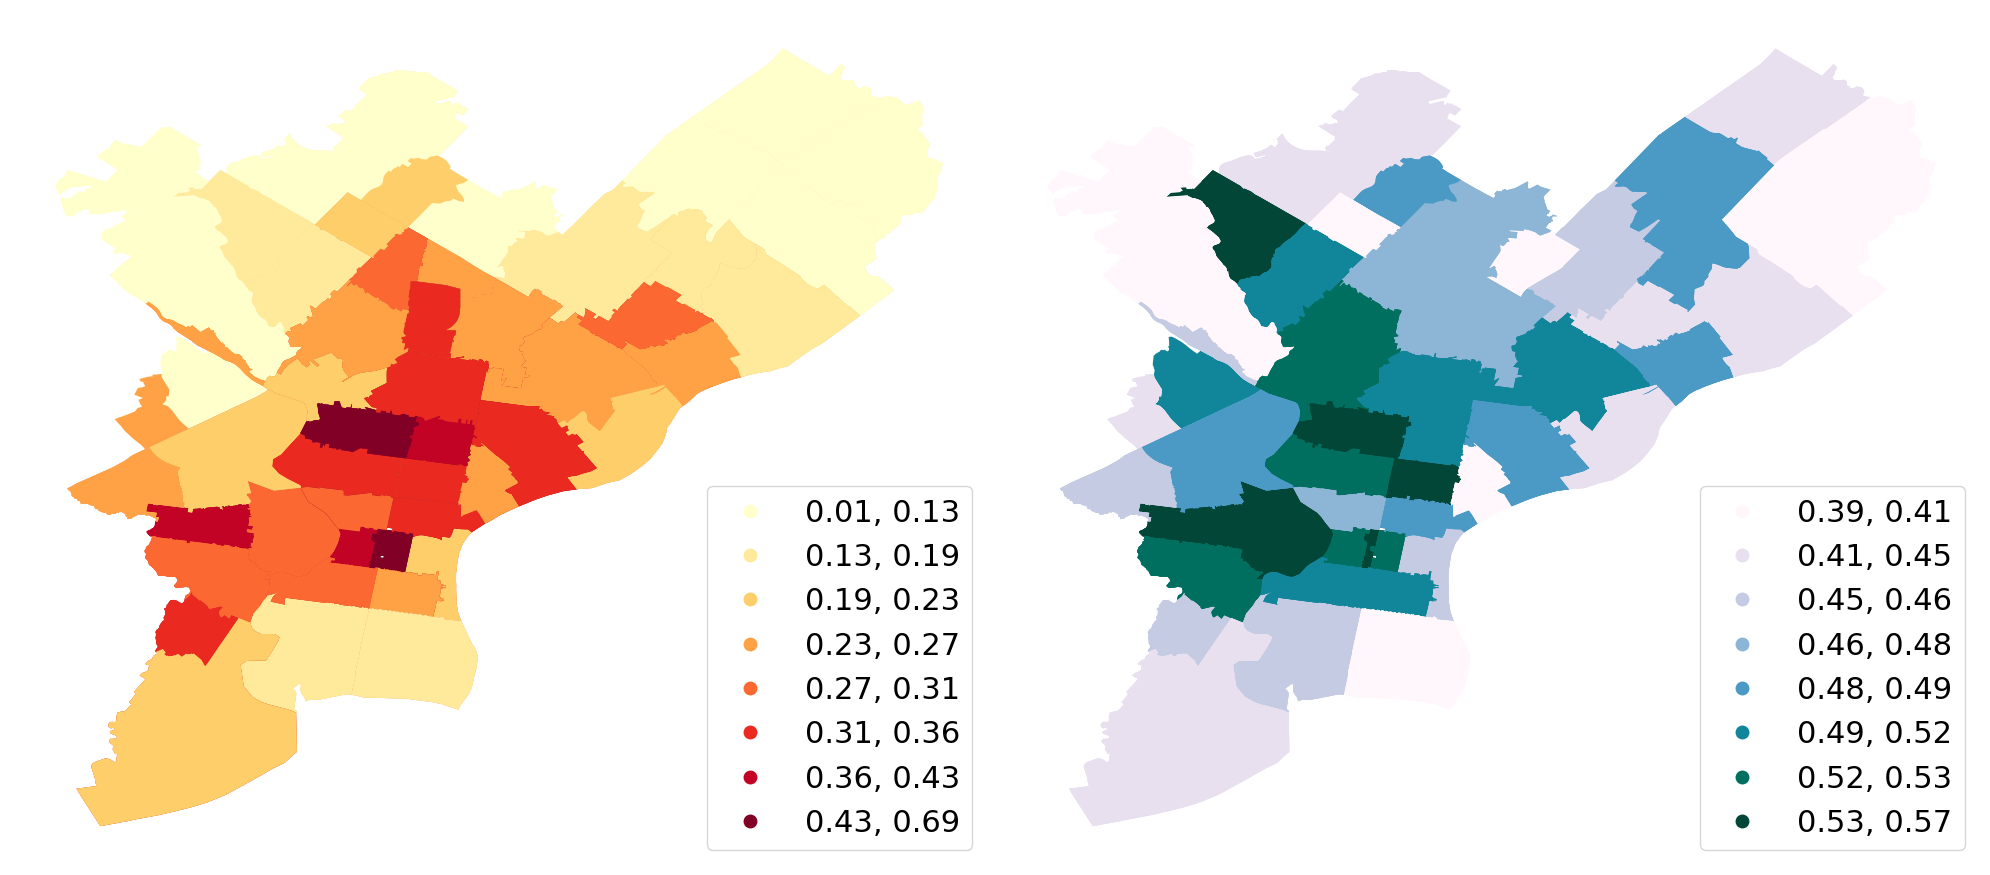

In [5]:
# Crear una figura con subplots lado a lado
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Mapa 1: Risk Score
map1 = aggregate_df_train.plot(column='risk_score', 
                              scheme='quantiles',
                              k=8, 
                              cmap='YlOrRd',
                              legend=True,
                              ax=axes[0],
                              legend_kwds={'loc': 'lower right', 'fontsize':'22'})
axes[0].set_axis_off()
# axes[0].set_title('Distribución del Score de Riesgo', fontsize=14, pad=20)

# Mapa 2: Gini Index
map2 = aggregate_df_train.plot(column='GiniIndex', 
                              scheme='quantiles',
                              k=8, 
                              cmap='PuBuGn',
                              legend=True,
                              ax=axes[1],
                              legend_kwds={'loc': 'lower right', 'fontsize':'22'})
axes[1].set_axis_off()
# axes[1].set_title('Distribución del Índice de Gini', fontsize=14, pad=20)

# Ajustar el espacio entre subplots
plt.tight_layout()

# Mostrar la figura
plt.show()

# Matriz de pesos Espaciales

In [6]:
wq = weights.contiguity.Queen.from_dataframe(aggregate_df_train)
wq.transform = 'r'

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_1904\118154908.py:1: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  wq = weights.contiguity.Queen.from_dataframe(aggregate_df_train)


In [7]:
print(wq.n)

150


In [8]:
# No hay islas
wq.islands

[]

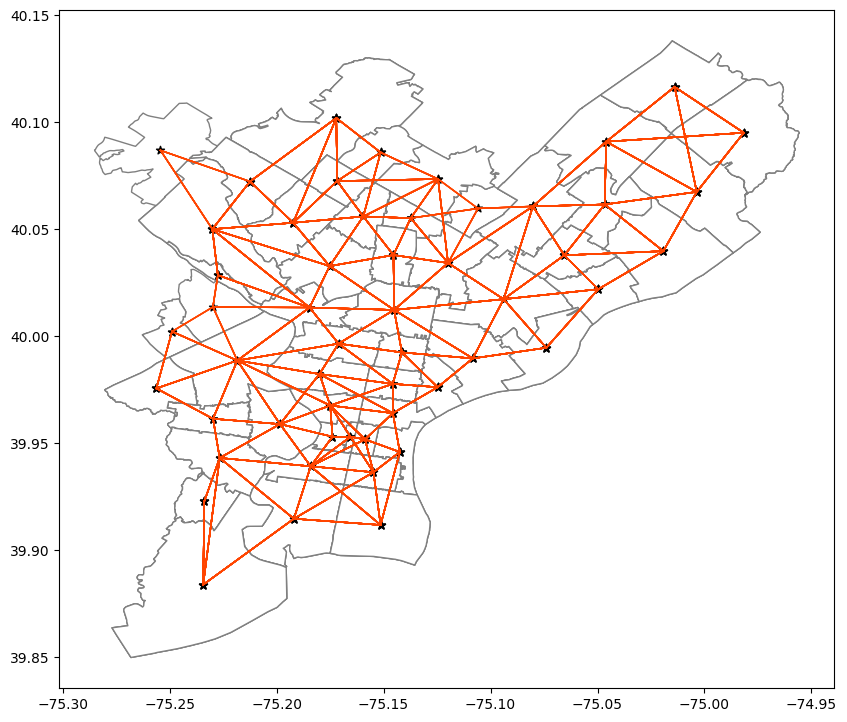

In [9]:
# Plot graph connections
ax = aggregate_df_train.plot(
        edgecolor="grey", facecolor="w",
        figsize=(10,10)
    )

wq.plot(
    aggregate_df_train,
    edge_kws=dict(linewidth=1, color="orangered"),
    node_kws=dict(marker="*"),
    ax=ax
)

plt.show()

## Retardo Espacial

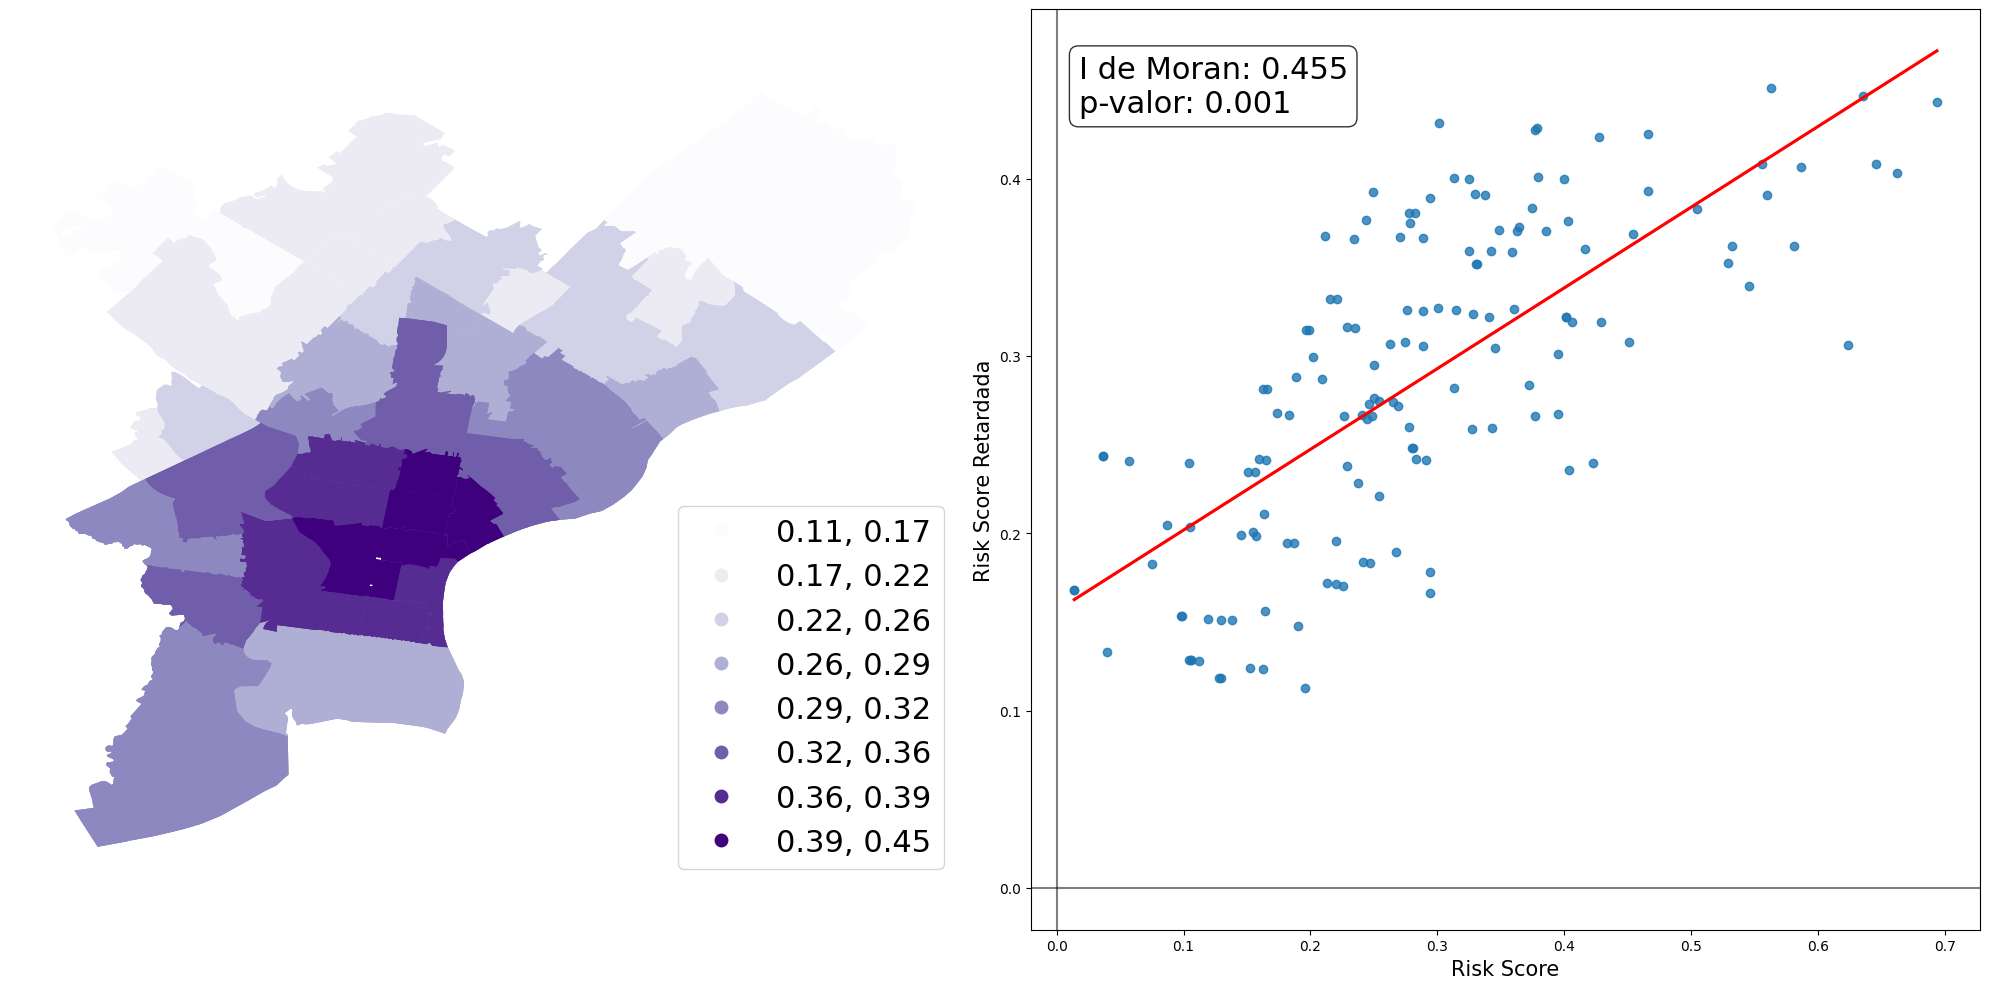

In [10]:
# Creación de variables con retardo espacial
aggregate_df_train["risk_score_lag"] = weights.spatial_lag.lag_spatial(
    wq, aggregate_df_train["risk_score"]
)

# Crear una figura con subplots lado a lado
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Mapa: Risk Score Retardada
map1 = aggregate_df_train.plot(column='risk_score_lag', 
                              scheme='quantiles',
                              k=8, 
                              cmap='Purples',
                              legend=True,
                              ax=axes[0],
                              legend_kwds={'loc': 'lower right', 'fontsize':'22'})
axes[0].set_axis_off()
# axes[0].set_title('Risk Score con Retardo Espacial', fontsize=14, pad=20)

# Diagrama de Moran con estadísticas
sns.regplot(
    x="risk_score",
    y="risk_score_lag",
    ci=None,
    data=aggregate_df_train,
    line_kws={"color": "r"},
    ax=axes[1]
)
axes[1].axvline(0, c="k", alpha=0.5)
axes[1].axhline(0, c="k", alpha=0.5)

# Calcular la I de Moran
moran = esda.moran.Moran(aggregate_df_train["risk_score"], wq)

# Añadir las estadísticas al gráfico
# Añadir las estadísticas dentro del gráfico
axes[1].text(0.05, 0.95, f"I de Moran: {moran.I:.3f}\np-valor: {moran.p_sim:.3f}", 
            transform=axes[1].transAxes, fontsize=22, verticalalignment='top',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
axes[1].set_xlabel('Risk Score', fontsize=15)
axes[1].set_ylabel('Risk Score Retardada', fontsize=15)

# Ajustar el espacio entre subplots
plt.tight_layout()

# Mostrar la figura
plt.show()

## Correlación Local

In [11]:
#Correlación Espacial Local
lisa = esda.moran.Moran_Local(aggregate_df_train["risk_score"], wq, seed=42)

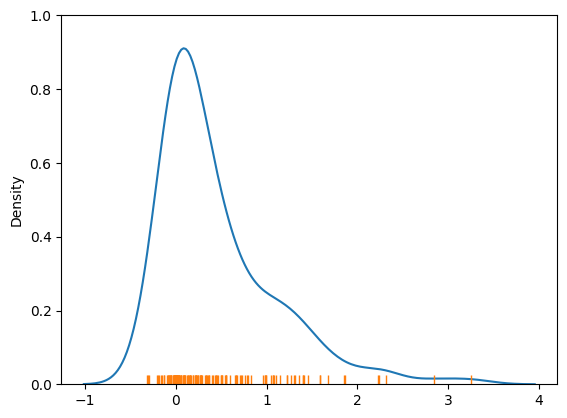

In [12]:
#Correlación Espacial Local
#Representación del Indice de Moran Local (Is)
# Draw KDE line
ax = sns.kdeplot(lisa.Is)
# Add one small bar (rug) for each observation
# along horizontal axis
sns.rugplot(lisa.Is, ax=ax);

In [13]:
# # Set up figure and axes
# f, axs = plt.subplots(nrows=2, ncols=2, figsize=(14, 12))
# # Make the axes accessible with single indexing
# axs = axs.flatten()

# # Subplot 1 #
# # Choropleth of local statistics
# # Grab first axis in the figure
# ax = axs[0]
# # Assign new column with local statistics on-the-fly
# aggregate_df_train.assign(
#     Is=lisa.Is
#     # Plot choropleth of local statistics
# ).plot(
#     column="Is",
#     cmap="PuBuGn",
#     scheme="quantiles",
#     k=5,
#     edgecolor="white",
#     linewidth=0.1,
#     alpha=0.75,
#     legend=True,
#     ax=ax,
# )

# # Subplot 2 #
# # Quadrant categories
# # Grab second axis of local statistics
# ax = axs[1]
# # Plot Quandrant colors (note to ensure all polygons are assigned a
# # quadrant, we "trick" the function by setting significance level to
# # 1 so all observations are treated as "significant" and thus assigned
# # a quadrant color
# esdaplot.lisa_cluster(lisa, aggregate_df_train, p=1, ax=ax)

# # Subplot 3 #
# # Significance map
# # Grab third axis of local statistics
# ax = axs[2]
# #
# # Find out significant observations
# labels = pd.Series(
#     1 * (lisa.p_sim < 0.05),  # Assign 1 if significant, 0 otherwise
#     index=aggregate_df_train.index  # Use the index in the original data
#     # Recode 1 to "Significant and 0 to "Non-significant"
# ).map({1: "Significant", 0: "Non-Significant"})
# # Assign labels to `db` on the fly
# aggregate_df_train.assign(
#     cl=labels
#     # Plot choropleth of (non-)significant areas
# ).plot(
#     column="cl",
#     categorical=True,
#     k=2,
#     cmap="Paired",
#     linewidth=0.1,
#     edgecolor="white",
#     legend=True,
#     ax=ax,
# )


# # Subplot 4 #
# # Cluster map
# # Grab second axis of local statistics
# ax = axs[3]
# # Plot Quandrant colors In this case, we use a 5% significance
# # level to select polygons as part of statistically significant
# # clusters
# esdaplot.lisa_cluster(lisa, aggregate_df_train, p=0.05, ax=ax)

# # Figure styling #
# # Set title to each subplot
# for i, ax in enumerate(axs.flatten()):
#     ax.set_axis_off()
#     ax.set_title(
#         [
#             "Local Statistics",
#             "Scatterplot Quadrant",
#             "Statistical Significance",
#             "Moran Cluster Map",
#         ][i],
#         y=0,
#     )
# # Tight layout to minimise in-betwee white space
# # f.tight_layout()

# # Display the figure
# plt.show()

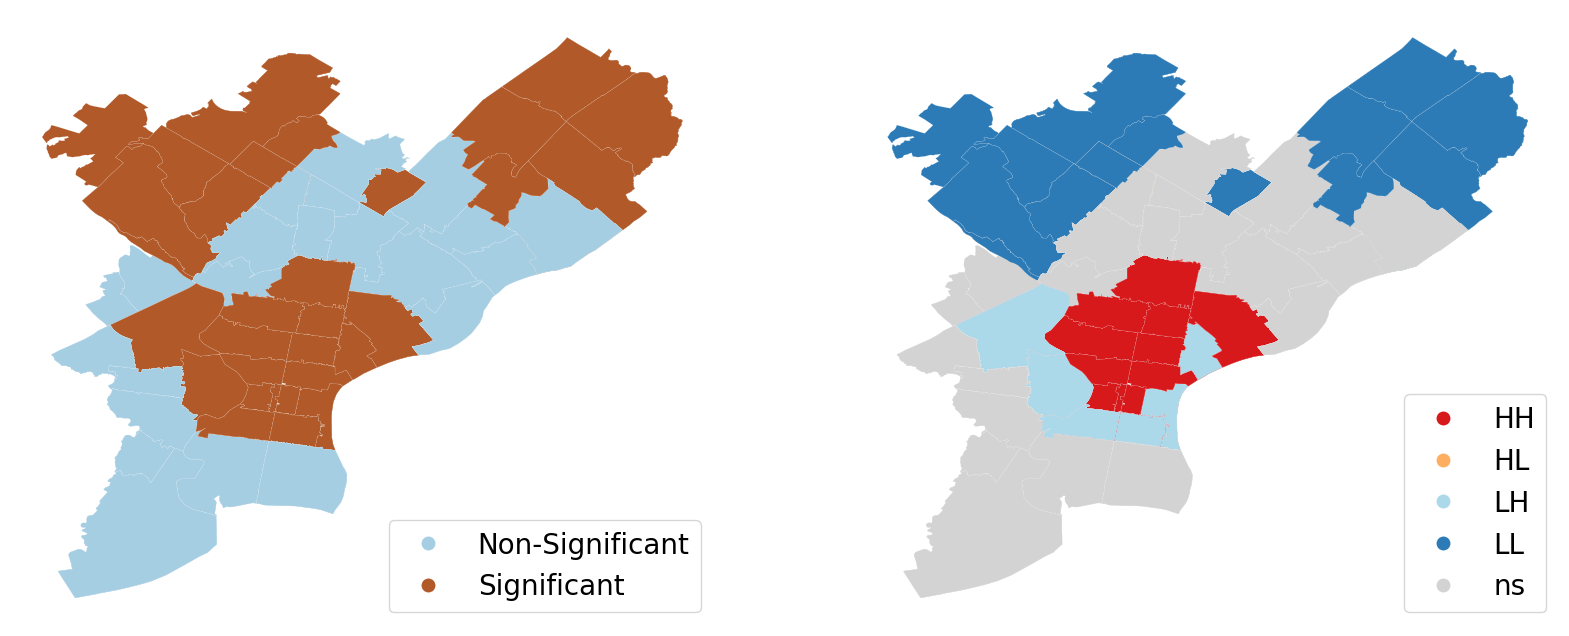

In [14]:
# Set up figure and axes
f, axs = plt.subplots(nrows=1, ncols=2, figsize=(20, 10))
# Make the axes accessible with single indexing
axs = axs.flatten()

# Subplot 1 #
# Significance map
# Grab third axis of local statistics
ax = axs[0]
#
# Find out significant observations
labels = pd.Series(
    1 * (lisa.p_sim < 0.05),  # Assign 1 if significant, 0 otherwise
    index=aggregate_df_train.index  # Use the index in the original data
    # Recode 1 to "Significant and 0 to "Non-significant"
).map({1: "Significant", 0: "Non-Significant"})
# Assign labels to `db` on the fly
aggregate_df_train.assign(
    cl=labels
    # Plot choropleth of (non-)significant areas
).plot(
    column="cl",
    categorical=True,
    k=2,
    cmap="Paired",
    linewidth=0.1,
    edgecolor="white",
    legend=True,
    ax=ax,
    legend_kwds={'loc': 'lower right', 'fontsize':'20'}
)


# Subplot 4 #
# Cluster map
# Grab second axis of local statistics
ax = axs[1]
# Plot Quandrant colors In this case, we use a 5% significance
# level to select polygons as part of statistically significant
# clusters
esdaplot.lisa_cluster(lisa, aggregate_df_train, p=0.05, ax=ax, legend_kwds={'loc': 'lower right', 'fontsize':'20'})

# Figure styling #
# Set title to each subplot
for i, ax in enumerate(axs.flatten()):
    ax.set_axis_off()
    # ax.set_title(
    #     [
    #         "Significancia Estadística por Área Postal",
    #         "Cluster de Moran",
    #     ][i],
    #     y=0,
    # )
# Tight layout to minimise in-betwee white space
# f.tight_layout()

# Display the figure
plt.show()

In [15]:
# Assign pseudo P-values to `gdfm`
aggregate_df_train["p-sim"] = lisa.p_sim
# `1` if significant (at 5% confidence level), `0` otherwise
sig = 1 * (lisa.p_sim < 0.05)
# Assign significance flag to `db`
aggregate_df_train["sig"] = sig

# Pick as part of a quadrant only significant polygons,
# assign `0` otherwise (Non-significant polygons)
spots = lisa.q * sig
# Mapping from value to name (as a dict)
spots_labels = {
    0: "Non-Significant",
    1: "HH",
    2: "LH",
    3: "LL",
    4: "HL",
}
# Create column in `db` with labels for each polygon
aggregate_df_train["labels"] = pd.Series(
    # First initialise a Series using values and `db` index
    spots,
    index=aggregate_df_train.index
    # Then map each value to corresponding label based
    # on the `spots_labels` mapping
).map(spots_labels)
# Print top for inspection
aggregate_df_train["labels"].value_counts()

labels
Non-Significant    60
HH                 41
LL                 36
LH                 10
HL                  3
Name: count, dtype: int64

In [16]:
# Se une la información agregada del análisis espacial a la base de datos original 
df_train_with_lag = df_train.merge(
    right=aggregate_df_train[['ZCTA', 'time_of_day', 'risk_score_lag', 'sig', 'labels']],
    on=['ZCTA', 'time_of_day'],
    how='left'
)

In [ ]:
df_train_with_lag.head(3)

# Modelado

## Modelo sin componente espacial

In [ ]:
df_train.head(3)

In [ ]:
train = aggregate_df_train.copy()

In [ ]:
#Regresión MCO
m1 = spreg.OLS(
    # Dependent variable
    train[["risk_score"]].values,
    # Independent variables
    train[["GiniIndex"]].values,
    # Dependent variable name
    name_y="risk_score",
    # Independent variable name
    name_x=["GiniIndex"]
)

print(m1.summary)

In [ ]:
# Verificar dimensiones
print(f"Dimensiones de wq: {wq.n}")
print(f"Dimensiones de residuos: {len(m1.u)}")
print(f"Dimensiones de train: {len(train)}")

In [ ]:
# Create column with residual values from m1
train["residual"] = m1.u
train["lag_residual"] = weights.spatial_lag.lag_spatial(wq, m1.u)

f, ax = plt.subplots(1, figsize=(9, 9))
sns.regplot(
    x="residual",
    y="lag_residual",
    ci=None,
    data=train,
    line_kws={"color": "r"},
)
ax.axvline(0, c="k", alpha=0.5)
ax.axhline(0, c="k", alpha=0.5)
ax.set_title("Moran Plot - Residuos Modelo Regresión")
plt.show()

In [ ]:
# Correlación Espacial: La I de Moran
moran = esda.moran.Moran(train["residual"], wq)
print("I de moran:", moran.I.round(3))
print("p-valor:", moran.p_sim)

In [ ]:
# representación de los residuos MCO  retardada
map=train.plot(column='residual', 
         scheme='quantiles',
         k=8, cmap='PuBuGn',
         legend=True,
         figsize=(10,10),
         legend_kwds={'loc': 'lower right', 'fontsize':'8', 'title':'Residuos MCO'} 
)
map.set_axis_off()

## Modelo Espacial

In [ ]:
train.columns

In [ ]:
# Reordenar para que Morning sea la primera categoría alfabéticamente
train["time_of_day_reordered"] = train["time_of_day"].replace({
    'Afternoon': 'B_Afternoon',  # B para que sea segunda
    'Morning': 'A_Morning',      # A para que sea primera (se elimina)
    'Night': 'C_Night'           # C para que sea tercera
})

# Crear dummies (ahora Morning se eliminará)
dummies = pd.get_dummies(train["time_of_day_reordered"], prefix="time", drop_first=True)

# Limpiar nombres de columnas
dummies.columns = [col.replace('time_B_', 'time_').replace('time_C_', 'time_') 
                   for col in dummies.columns]

# Concatenar con tus features
X = pd.concat([train[["GiniIndex"]], dummies], axis=1).astype(float).values
y = train[["risk_score"]].values

In [ ]:
# Concatenar con tus features
# X = train[["GiniIndex"]].astype(float).values
# y = train[["risk_score"]].values

In [ ]:
# (Modelo autoregresivo espacial - estimado por MC2E)
mLag = spreg.GM_Lag(    
    # Dependent variable
    y=y,
    # Independent variables
    x=X,
    # Spatial weights matrix
    w= wq,
    robust='white',
    # Numero de retardos
    w_lags=3,
    #para el modelo de durbin slx_lags >0
    # slx_lags = 1, 
    #diagnósitico de correlación espacial
    spat_diag=True,
    # Dependent variable name
    name_y="risk_score",
    # Independent variable name
    name_x=["GiniIndex", 'Afternoon', 'Night'], #, 'time_Afternoon', 'time_Night' 
    name_w=" Contiguidad Reina",
    name_ds=" Índice de Criminalidad en Filadelfia"
    
)

print(mLag.summary)

In [ ]:
# Create column with residual values from m1
train["mLagresidual"] = mLag.u
train["mLagresidual_lag"] = weights.spatial_lag.lag_spatial(wq, mLag.u)

f, ax = plt.subplots(1, figsize=(9, 9))
sns.regplot(
    x="mLagresidual",
    y="mLagresidual_lag",
    ci=None,
    data=train,
    line_kws={"color": "r"},
)
ax.axvline(0, c="k", alpha=0.5)
ax.axhline(0, c="k", alpha=0.5)
ax.set_title("Moran Plot - Residuos Modelo Regresión Espacial")
plt.show()

In [ ]:
# representación de los residuos Modelo Retardado
map=train.plot(column='mLagresidual', 
         scheme='quantiles',
         k=8, cmap='PuBuGn',
         legend=True,
         figsize=(10,10),
         legend_kwds={'loc': 'lower right', 'fontsize':'8', 'title':'Residuos Modelo Retardos'} 
)
map.set_axis_off() 


### Predicciones

In [ ]:
df_test = cleanDataframe2(df=gpd.read_file('../Input/ModelingDatasets/Test/df_test_with_score_ZCTACoordinates.shp'))
df_test = df_test[(df_test['date'] >= '2025-01-01')]

In [ ]:
# Se hace agrupamiento
aggregate_df_test_raw = df_test.groupby(['ZCTA', 'time_of_day']).agg({
    'geometry': 'first',
    'population' : 'first',
    'white_race':'first',
    'black_race':'first',
    'latino_race':'first',
    'asian_race':'first',
    'mean_income': 'first',
    'median_income' :'first',
    'total_households': 'first',
    'household_25k_or_less': 'first',
    'household_25k_to_50k': 'first',
    'household_50k_to_150k':'first',
    'household_150k_or_more': 'first',
    'GiniIndex': 'first',
    'risk_score': 'mean',
}).reset_index()

# aggregate_df_test_raw.to_csv("RiskScore_MediaZCTA_Test.csv")

# Se remueven NAs
aggregate_df_test = aggregate_df_test_raw.dropna().reset_index()

# Asegurar que sigue siendo GeoDataFrame
aggregate_df_test = gpd.GeoDataFrame(aggregate_df_test, geometry='geometry')

In [ ]:
test = aggregate_df_test.copy()

In [ ]:
# Crear matriz de pesos de contigüidad reina para validación
wq_test = weights.Queen.from_dataframe(test)

# Normalizar (como hiciste en training)
wq_test.transform = 'r'

In [ ]:
# Reordenar para que Morning sea la primera categoría alfabéticamente
test["time_of_day_reordered"] = test["time_of_day"].replace({
    'Afternoon': 'B_Afternoon',  # B para que sea segunda
    'Morning': 'A_Morning',      # A para que sea primera (se elimina)
    'Night': 'C_Night'           # C para que sea tercera
})

# Crear dummies (ahora Morning se eliminará)
dummies = pd.get_dummies(test["time_of_day_reordered"], prefix="time", drop_first=True)

# Limpiar nombres de columnas
dummies.columns = [col.replace('time_B_', 'time_').replace('time_C_', 'time_') 
                   for col in dummies.columns]

# Concatenar con tus features
X_val = pd.concat([test[["GiniIndex"]], dummies], axis=1).astype(float).values
y_val = test[["risk_score"]].values

In [ ]:
# Concatenar con tus features
X_val = test[["GiniIndex"]].astype(float).values
y_val = test[["risk_score"]].values

In [ ]:
betas = np.array(mLag.betas).flatten()
intercept = betas[0]
coefs = betas[1:-1]   # todas las covariables excepto rho
rho = betas[-1]

# Construcción de Xβ con todas las variables de una vez
Xbeta = intercept + X_val.dot(coefs)

In [ ]:
# 3) Matriz de pesos espaciales (misma del entrenamiento)
W_test, ids = wq_test.full()
n = W_test.shape[0]

In [ ]:
# 4) Resolver el sistema (I - rho W) y = Xβ
I = np.eye(n)
M = I - rho * W_test   
Xbeta_vec = Xbeta.reshape(-1, 1)

In [ ]:
try:
    y_val_pred = np.linalg.solve(M, Xbeta_vec).flatten()
except np.linalg.LinAlgError:
    print("Advertencia: (I - rho W) es singular; usando pseudo-inversa")
    y_val_pred = np.linalg.pinv(M).dot(Xbeta_vec).flatten()

In [ ]:
y_val.flatten()

In [ ]:
y_val_pred

In [ ]:
# 1) Valores reales y predichos
y_true = y_val.flatten()
y_pred = y_val_pred

# 2) Métricas
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

# 3) Scatter plot Predicho vs Real
plt.figure(figsize=(7,7))
plt.scatter(y_true, y_pred, alpha=0.6, edgecolor="k")
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
plt.xlabel("Valores reales (y_val)")
plt.ylabel("Valores predichos (y_val_pred)")
plt.title(f"Predicho vs Real (RMSE={rmse:.3f}, R²={r2:.3f})")
plt.grid(True)
plt.show()

In [ ]:
df_resultados = pd.DataFrame({
    'y_true': y_val.flatten(),
    'y_pred': y_val_pred
})

df_resultados.head(100)

# Selección de Features para modelo ML

In [17]:
# Se hace copia del train
train = df_train_with_lag.dropna().copy()
del df_train_with_lag

# Carga datos del test
df_test = cleanDataframe2(gpd.read_file('../Input/ModelingDatasets/Test/df_test_with_score.shp'))
# Se hace join con el risk score lag que se calculó con el train
test = df_test.merge(
    right=aggregate_df_train[['ZCTA', 'time_of_day', 'risk_score_lag', 'sig', 'labels']],
    on=['ZCTA', 'time_of_day'],
    how='left'
)

del df_test

In [18]:
# Versión más concisa
pd.concat([
    train['risk_level'].value_counts(normalize=True),
    test['risk_level'].value_counts(normalize=True)
], axis=1, keys=['Test', 'Train']).fillna(0)

,Test,Train
risk_level,,
Low,0.828659,0.837608
High,0.171341,0.162392


In [19]:
# Transformaciones de variables
train['white_population'] = (train['white_race']) / train['population']
train['non_white_population'] =  (train['black_race'] + train['latino_race'] + train['asian_race']) / train['population']

train["hour_sin"] = np.sin(2 * np.pi * train["hour"] / 24)
train["hour_cos"] = np.cos(2 * np.pi * train["hour"] / 24)

test['white_population'] = (test['white_race']) / test['population']
test['non_white_population'] =  (test['black_race'] + test['latino_race'] + test['asian_race']) / test['population']

test["hour_sin"] = np.sin(2 * np.pi * test["hour"] / 24)
test["hour_cos"] = np.cos(2 * np.pi * test["hour"] / 24)

## Variable Respuesta (Risk Score) 

In [ ]:
train['risk_score'].describe()

In [ ]:
sns.regplot(
    x='risk_score_lag',
    y='risk_score',
    data=train,
    ci=None,
    line_kws={"color": "r"},
    
)

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=train, x='risk_level', palette='viridis', 
              order=train['risk_level'].value_counts().index)
plt.xlabel('Categoría de Riesgo', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.xticks(rotation=45)

# Añadir valores encima de cada barra
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=10)
                
plt.tight_layout()
plt.show()

## Variables Categóricas

In [ ]:
# Analizamos la cardinalidad de las variables categóricas
lista_cat = [
    'dc_dist', 'psa', 'hour', 'time_of_day',
    'day_of_week', 'week_of_year', 'month', 'season', 
    'is_holiday','ZCTA', 'sig', 'labels'
]

df_train_with_lag[lista_cat].nunique().sort_values(ascending = False)

#### Hour

Notamos que la mayoría de crímenes sucenden durante el día, puntualmente entre 10am y las 6pm, lo cual hace sentido porque justamente es en estas horas donde hay mayor actividad poblacional.

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6))  # 2 filas, 1 columna

# Primer gráfico: histograma de crímenes por hora
sns.histplot(data=train, x='hour', bins=24, kde=True, ax=axes[0])
axes[0].set_title('Distribución de Crímenes por Hora del Día')
axes[0].set_xlabel('Hora')
axes[0].set_ylabel('Número de Crímenes')
axes[0].set_xticks(range(0, 24))

# Segundo gráfico: boxplot de risk_score por hora
sns.boxplot(data=train, x='hour', y='risk_score', ax=axes[1])
axes[1].set_title('Distribución de Risk Score por Hora del Día')
axes[1].set_xlabel('Hora')
axes[1].set_ylabel('Risk score')
axes[1].set_xticks(range(0, 24))

plt.tight_layout()  # Ajusta para que no se monten los títulos y etiquetas
plt.show()

In [ ]:
chi2_cramersv(df = train, target='risk_level', cat_vars=['hour'])

#### Time of Day

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))  # 2 filas, 1 columna

# Primer gráfico: violinplot de risk_score por momento del día
sns.violinplot(data=train, x='time_of_day', y='risk_score', ax=axes[0])
axes[0].set_title('Distribución de Risk Score por Momento del Día')
axes[0].set_xlabel('Momento del día')
axes[0].set_ylabel('Risk score')

# Segundo gráfico: porcentaje de crímenes por momento del día con V de Cramér
counts = train['time_of_day'].value_counts(normalize=True) * 100
bars = axes[1].bar(counts.index, counts.values, color='skyblue')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].set_xlabel('Momento del día')
axes[1].set_ylim(0, 100)

# Etiquetas en cada barra
for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', ha='center', fontsize=10)

# Añadir texto V de Cramér
cramerV = chi2_cramersv(df=train, target='risk_level', cat_vars=['time_of_day'])
axes[1].text(1.50, 84, f"V de Cramér: {round(cramerV['cramers_v'].iloc[0], 4):.4f}", fontsize=10)

plt.tight_layout()
plt.show()

#### Dc_District 

In [ ]:
# Crear gráfico
plt.figure(figsize=(12,6))
bars = plt.bar(counts.index.astype(str), counts.values, color='skyblue')  # ← Convertir a string
plt.title('Porcentaje (%) de crímenes por distrito policial', fontsize=14)
plt.ylabel('Porcentaje (%)')
plt.xlabel('Código del distrito')
plt.ylim(0, 15)
# Etiquetas en cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', ha='center', fontsize=10, rotation=90)
# Añadir texto V de Cramér
plt.text(len(counts)-4, 13, f"V de Cramér: {round(cramerV['cramers_v'].iloc[0], 4):.4f}", fontsize=10)
plt.tight_layout()
plt.show()

# Se compara con el risk score mediante un boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(data=train, x='dc_dist', y = 'risk_score')
plt.xlabel('Código del distrito')
plt.ylabel('Risk score')
plt.show()

# V de Cramer
cramerV = chi2_cramersv(df = train, target='risk_level', cat_vars=['dc_dist'])

# Porcentajes
counts = train['dc_dist'].value_counts(normalize=True) * 100

In [ ]:
# Se procederá a hacer una agrupación con base en la media de nuestra variable target
target_mean = train.groupby('dc_dist')['risk_score'].agg(['mean']).reset_index().sort_values(by = 'mean', ascending=False)

thresholds = {
    'Rojo': 0.5,     # >= 0.4
    'Naranja': 0.4, # 0.25 - 0.4
    'Amarillo': 0.3, 
    'Verde': 0.20      # < 0.15
}

# La lógica de agrupación 
def categorizar_dc_dist(mean_value):
    if mean_value >= thresholds['Rojo']:
        return 'Rojo'
    elif mean_value >= thresholds['Naranja']:
        return 'Naranja'
    elif mean_value >= thresholds['Amarillo']:
        return 'Amarillo'
    else:
        return 'Verde'
    
# Se crea nueva columna 
target_mean['dc_dist_grouped'] = target_mean['mean'].apply(categorizar_dc_dist)

In [ ]:
# Merge con la data inicial
train = train.merge(target_mean[['dc_dist', 'dc_dist_grouped']], how='left', on = 'dc_dist')

In [ ]:
# V de Cramer
cramerV = chi2_cramersv(df = train, target='risk_level', cat_vars=['dc_dist_grouped'])

# Porcentajes
counts = train['dc_dist_grouped'].value_counts(normalize=True) * 100

# Crear gráfico
plt.figure(figsize=(8,5))
bars = plt.bar(counts.index.astype(str), counts.values, color='skyblue')  # ← Convertir a string
plt.title('Porcentaje (%) de crímenes por distrito policial agrupado por riesgo', fontsize=14)
plt.ylabel('Porcentaje (%)')
plt.xlabel('Riesgo agrupado por código del distrito')
plt.ylim(0, 70)
# Etiquetas en cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', ha='center', fontsize=10, rotation=90)
# Añadir texto V de Cramér
plt.text(len(counts)-1.5, 55, f"V de Cramér: {round(cramerV['cramers_v'].iloc[0], 4):.4f}", fontsize=10)
plt.tight_layout()
plt.show()

#### Psa

In [ ]:
# V de Cramer
cramerV = chi2_cramersv(df = train, target='risk_level', cat_vars=['psa'])

# Porcentajes
counts = train['psa'].value_counts(normalize=True) * 100

# Crear gráfico
plt.figure(figsize=(8,5))
bars = plt.bar(counts.index.astype(str), counts.values, color='skyblue')  # ← Convertir a string
plt.title('Porcentaje (%) de crímenes por área de servicio policial', fontsize=14)
plt.ylabel('Porcentaje (%)')
plt.xlabel('Código del distrito')
plt.ylim(0, 50)
# Etiquetas en cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', ha='center', fontsize=10, rotation=90)
# Añadir texto V de Cramér
plt.text(len(counts)-2.0, 45, f"V de Cramér: {round(cramerV['cramers_v'].iloc[0], 4):.4f}", fontsize=10)
plt.tight_layout()
plt.show()

# Se compara con el risk score mediante un boxplot
plt.figure(figsize=(12, 6))
sns.violinplot(data=train, x='psa', y = 'risk_score')
plt.xlabel('Momento del día')
plt.ylabel('Risk score')
plt.show()

#### Month

In [ ]:
# Se compara con el risk score mediante un boxplot
plt.figure(figsize=(12, 6))
sns.violinplot(data=train, x='month', y = 'risk_score')
plt.title('Distribución de Crímenes por Hora del Día')
plt.xlabel('Momento del día')
plt.ylabel('Risk score')
plt.show()

In [ ]:
# V de Cramer
cramerV = chi2_cramersv(df = train, target='risk_level', cat_vars=['month'])

order = list(calendar.month_name)[1:]

# Porcentajes
counts = train['month'].value_counts(normalize=True) * 100
counts = counts.reindex(order).dropna()

# Crear gráfico
plt.figure(figsize=(8,5))
bars = plt.bar(counts.index, counts.values, color='skyblue')  # ← Convertir a string
plt.title('Porcentaje (%) de crímenes por mes', fontsize=14)
plt.ylabel('Porcentaje (%)')
plt.xlabel('Cantidad de crímenes por mes')
plt.ylim(0, 70)
plt.xticks(rotation=45, ha='right')
# Etiquetas en cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', ha='center', fontsize=10, rotation=90)
# Añadir texto V de Cramér
plt.text(len(counts)-3.25, 55, f"V de Cramér: {round(cramerV['cramers_v'].iloc[0], 4):.4f}", fontsize=10,)
plt.tight_layout()
plt.show()

#### Season

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))  # 1 fila, 2 columnas

# ------------------------------
# Gráfico 1: porcentaje de crímenes por temporada
# ------------------------------
cramerV = chi2_cramersv(df=train, target='risk_level', cat_vars=['season'])

counts = train['season'].value_counts(normalize=True) * 100
bars = axes[0].bar(counts.index, counts.values, color='skyblue')

axes[0].set_title('Porcentaje (%) de crímenes por temporada', fontsize=14)
axes[0].set_ylabel('Porcentaje (%)')
axes[0].set_xlabel('Temporada')
axes[0].set_ylim(0, 50)
axes[0].set_xticklabels(counts.index, rotation=45, ha='right')

# Etiquetas en cada barra
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, height + 1,
                 f'{height:.1f}%', ha='center', fontsize=10, rotation=90)

# Texto V de Cramér
axes[0].text(len(counts)-1.50, 42,
             f"V de Cramér: {round(cramerV['cramers_v'].iloc[0], 4):.4f}",
             fontsize=10)

# ------------------------------
# Gráfico 2: violinplot risk_score vs season
# ------------------------------
sns.violinplot(data=train, x='season', y='risk_score', ax=axes[1])
axes[1].set_title('Distribución de Risk Score por Temporada')
axes[1].set_xlabel('Temporada')
axes[1].set_ylabel('Risk score')

plt.tight_layout()
plt.show()

#### Week day

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))  # 1 fila, 2 columnas

# ------------------------------
# Gráfico 1: porcentaje de crímenes por temporada
# ------------------------------
cramerV = chi2_cramersv(df=train, target='risk_level', cat_vars=['day_of_week'])

counts = train['day_of_week'].value_counts(normalize=True) * 100
bars = axes[0].bar(counts.index, counts.values, color='skyblue')

axes[0].set_title('Porcentaje (%) de crímenes por día de la semana', fontsize=14)
axes[0].set_ylabel('Porcentaje (%)')
axes[0].set_xlabel('Día de la semana')
axes[0].set_ylim(0, 50)
axes[0].set_xticklabels(counts.index, rotation=45, ha='right')

# Etiquetas en cada barra
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, height + 1,
                 f'{height:.1f}%', ha='center', fontsize=10, rotation=90)

# Texto V de Cramér
axes[0].text(len(counts)-2, 42,
             f"V de Cramér: {round(cramerV['cramers_v'].iloc[0], 4):.4f}",
             fontsize=10)

# ------------------------------
# Gráfico 2: violinplot risk_score vs season
# ------------------------------
sns.violinplot(data=train, x='day_of_week', y='risk_score', ax=axes[1])
axes[1].set_title('Distribución de Risk Score por día de la semana')
axes[1].set_xlabel('Día de la semana')
axes[1].set_ylabel('Risk score')

plt.tight_layout()
plt.show()

#### Holiday 

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))  # 1 fila, 2 columnas

# ------------------------------
# Gráfico 1: porcentaje de crímenes por temporada
# ------------------------------
cramerV = chi2_cramersv(df=train, target='risk_level', cat_vars=['is_holiday'])

counts = train['is_holiday'].value_counts(normalize=True) * 100
bars = axes[0].bar(counts.index, counts.values, color='skyblue')

axes[0].set_title('Porcentaje (%) de crímenes por día festivo', fontsize=14)
axes[0].set_ylabel('Porcentaje (%)')
axes[0].set_xlabel('Día Festivo')
axes[0].set_ylim(0, 120)
axes[0].set_xticklabels(counts.index, rotation=45, ha='right')

# Etiquetas en cada barra
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, height + 1,
                 f'{height:.1f}%', ha='center', fontsize=10, rotation=90)

# Texto V de Cramér
axes[0].text(len(counts)-1, 95,
             f"V de Cramér: {round(cramerV['cramers_v'].iloc[0], 4):.4f}",
             fontsize=10)

# ------------------------------
# Gráfico 2: violinplot risk_score vs season
# ------------------------------
sns.violinplot(data=train, x='is_holiday', y='risk_score', ax=axes[1])
axes[1].set_title('Distribución de Risk Score por día festivo')
axes[1].set_xlabel('Día Festivo')
axes[1].set_ylabel('Risk score')

plt.tight_layout()
plt.show()

#### Significancia de Autocorrelacion Local

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))  # 1 fila, 2 columnas

# ------------------------------
# Gráfico 1: porcentaje de crímenes por temporada
# ------------------------------
cramerV = chi2_cramersv(df=train, target='risk_level', cat_vars=['sig'])

counts = train['sig'].value_counts(normalize=True) * 100
bars = axes[0].bar(counts.index, counts.values, color='skyblue')

axes[0].set_title('Porcentaje (%) de crímenes por significancia local de Moran', fontsize=14)
axes[0].set_ylabel('Porcentaje (%)')
axes[0].set_xlabel('Es significante')
axes[0].set_ylim(0, 120)
axes[0].set_xticklabels(counts.index, rotation=45, ha='right')

# Etiquetas en cada barra
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, height + 1,
                 f'{height:.1f}%', ha='center', fontsize=10, rotation=90)

# Texto V de Cramér
axes[0].text(len(counts)-1, 95,
             f"V de Cramér: {round(cramerV['cramers_v'].iloc[0], 4):.4f}",
             fontsize=10)

# ------------------------------
# Gráfico 2: violinplot risk_score vs season
# ------------------------------
sns.violinplot(data=train, x='sig', y='risk_score', ax=axes[1])
axes[1].set_title('Distribución de Risk Score por significancia local de Moran')
axes[1].set_xlabel('Es significante')
axes[1].set_ylabel('Risk score')

plt.tight_layout()
plt.show()

#### Dirección de Significancia

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))  # 1 fila, 2 columnas

# ------------------------------
# Gráfico 1: porcentaje de crímenes por temporada
# ------------------------------
cramerV = chi2_cramersv(df=train, target='risk_level', cat_vars=['labels'])

counts = train['labels'].value_counts(normalize=True) * 100
bars = axes[0].bar(counts.index, counts.values, color='skyblue')

axes[0].set_title('Porcentaje (%) de crímenes por dirección de significancia', fontsize=14)
axes[0].set_ylabel('Porcentaje (%)')
axes[0].set_xlabel('Dirección de asociación')
axes[0].set_ylim(0, 120)
axes[0].set_xticklabels(counts.index, rotation=45, ha='right')

# Etiquetas en cada barra
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, height + 1,
                 f'{height:.1f}%', ha='center', fontsize=10, rotation=90)

# Texto V de Cramér
axes[0].text(len(counts)-1.5, 95,
             f"V de Cramér: {round(cramerV['cramers_v'].iloc[0], 4):.4f}",
             fontsize=10)

# ------------------------------
# Gráfico 2: violinplot risk_score vs season
# ------------------------------
sns.violinplot(data=train, x='labels', y='risk_score', ax=axes[1])
axes[1].set_title('Distribución de Risk Score por dirección de significancia')
axes[1].set_xlabel('Dirección de asociación')
axes[1].set_ylabel('Risk score')

plt.tight_layout()
plt.show()

#### ZCTA

In [ ]:
# V de Cramer
cramerV = chi2_cramersv(df = train, target='risk_level', cat_vars=['ZCTA'])
cramerV

## Variables Numéricas

La mayoría de variables numéricas que hay corresponden a estadísticas socioeconómicas de las áreas ZCTA, por lo que se procede a aplicar la técnica de WOE para tramificar dichas variables. Para ello, es primero importante hacer el split entre train y test:

In [20]:
# Subdividimos la data en X_train, X_test, y_train, y_test

X_train = train.drop(['risk_score', 'risk_level'], axis = 1)
y_train = train['risk_level']
y_train = (y_train == 'High').astype(int)

X_test = test.drop(['risk_score', 'risk_level'], axis = 1)
y_test = test['risk_level']
y_test = (y_test == 'High').astype(int)

### Gini Index

In [ ]:
variable = 'GiniIndex'

optb = OptimalBinning(name=variable, dtype="numerical", solver="cp")
# Una vez definido podemos pasar a estimarlo
optb.fit(X_train[variable], y_train)
optb.splits

binning_table = optb.binning_table
binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.49)",77601,0.486009,71654,5947,0.076636,0.912808,0.295911,0.035756
1,"[0.49, 0.52)",34114,0.213653,28753,5361,0.157150,0.103438,0.002209,0.000276
2,"[0.52, 0.54)",27029,0.169280,16665,10364,0.383440,-1.101181,0.278463,0.033149
3,"[0.54, inf)",20926,0.131058,15240,5686,0.271719,-0.590237,0.054688,0.006738
4,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
5,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,159670,1.000000,132312,27358,0.171341,,0.631271,0.075920


In [ ]:
# Transformación WOE en el conjunto train
new_variable_name = f"{variable}_WOE"
X_train[new_variable_name] = optb.transform(X_train[variable].values, metric="woe")

# Transformación WOE en el conjunto test
new_variable_name = f"{variable}_WOE"
X_test[new_variable_name] = optb.transform(X_test[variable].values, metric="woe")

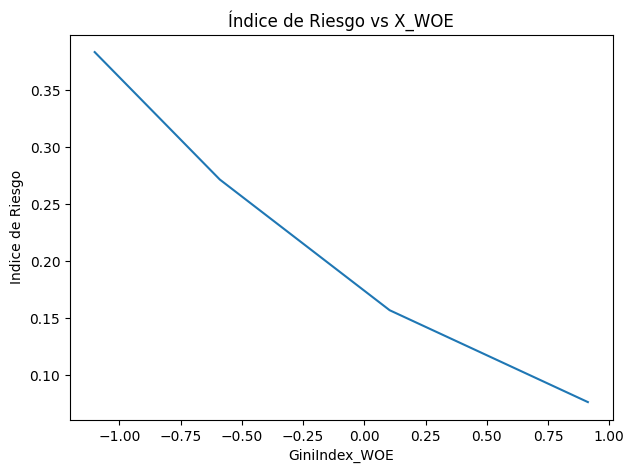

<Figure size 700x500 with 0 Axes>

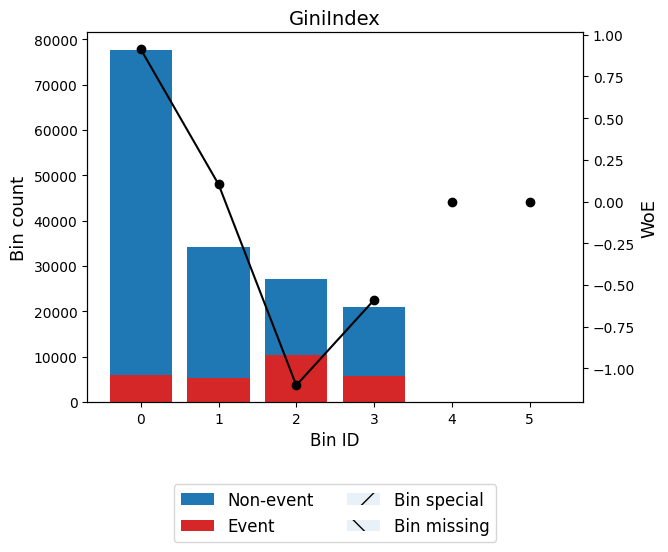

In [ ]:
# Crear el primer gráfico por separado
plt.figure(figsize=(7, 5))
plt.plot(pd.crosstab(X_train[new_variable_name].values, y_train, normalize=0).iloc[:,1])
plt.xlabel(new_variable_name)
plt.ylabel("Indice de Riesgo")
plt.title("Índice de Riesgo vs X_WOE")
plt.show()

# Crear el segundo gráfico por separado
plt.figure(figsize=(7, 5))
binning_table.plot(metric="woe")

### Mean Income

In [24]:
variable = 'mean_income'

optb = OptimalBinning(name=variable, dtype="numerical", solver="cp")
# Una vez definido podemos pasar a estimarlo
optb.fit(X_train[variable], y_train)
optb.splits

binning_table = optb.binning_table
binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 53386.00)",17575,0.110071,9461,8114,0.461679,-1.422567,0.320192,0.036958
1,"[53386.00, 59668.00)",22338,0.139901,14875,7463,0.334094,-0.886429,0.142154,0.017209
2,"[59668.00, 61270.50)",11236,0.070370,8303,2933,0.261036,-0.535563,0.023808,0.002941
3,"[61270.50, 117040.50)",84748,0.530770,80640,4108,0.048473,1.400905,0.643451,0.074439
4,"[117040.50, 153564.00)",14812,0.092766,13354,1458,0.098434,0.638597,0.030419,0.003739
5,"[153564.00, inf)",8961,0.056122,5679,3282,0.366254,-1.027832,0.079188,0.009485
6,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
7,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,159670,1.000000,132312,27358,0.171341,,1.239213,0.144770


In [25]:
# Transformación WOE en el conjunto train
new_variable_name = f"{variable}_WOE"
X_train[new_variable_name] = optb.transform(X_train[variable].values, metric="woe")

# Transformación WOE en el conjunto test
new_variable_name = f"{variable}_WOE"
X_test[new_variable_name] = optb.transform(X_test[variable].values, metric="woe")

### Hogares con ingresos anuales inferiores a los 25k

In [26]:
variable = 'household_25k_or_less'

optb, binning_table = optimal_binning(X_train, y_train, variable)
binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 20.85)",49580,0.310515,40732,8848,0.178459,-0.049331,0.000768,0.000096
1,"[20.85, 34.05)",66457,0.416215,61968,4489,0.067547,1.048834,0.319122,0.038157
2,"[34.05, 37.70)",26058,0.163199,20151,5907,0.226687,-0.349038,0.022204,0.002762
3,"[37.70, inf)",17575,0.110071,9461,8114,0.461679,-1.422567,0.320192,0.036958
4,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
5,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,159670,1.000000,132312,27358,0.171341,,0.662287,0.077972


In [27]:
# Transformación WOE en el conjunto train
new_variable_name = f"{variable}_WOE"
X_train[new_variable_name] = optb.transform(X_train[variable].values, metric="woe")

# Transformación WOE en el conjunto test
new_variable_name = f"{variable}_WOE"
X_test[new_variable_name] = optb.transform(X_test[variable].values, metric="woe")

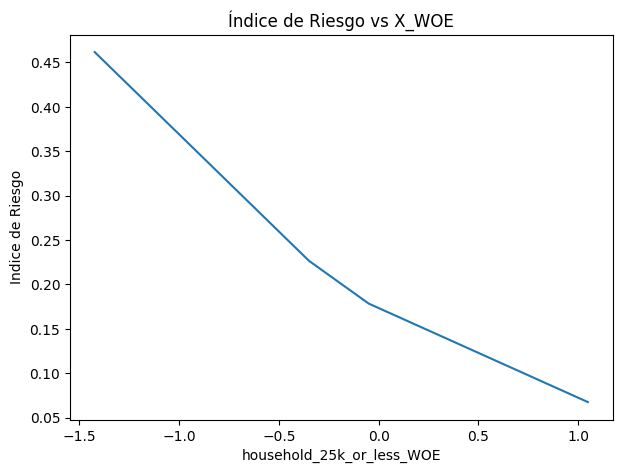

<Figure size 700x500 with 0 Axes>

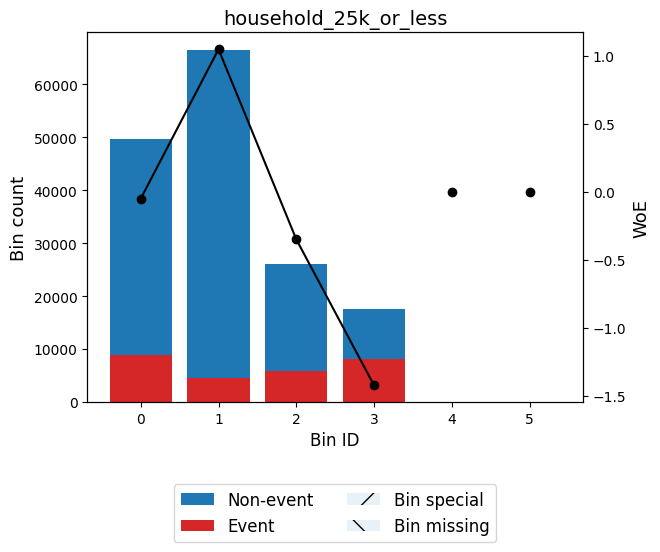

In [28]:
# Crear el primer gráfico por separado
plt.figure(figsize=(7, 5))
plt.plot(pd.crosstab(X_train[new_variable_name].values, y_train, normalize=0).iloc[:,1])
plt.xlabel(new_variable_name)
plt.ylabel("Indice de Riesgo")
plt.title("Índice de Riesgo vs X_WOE")
plt.show()

# Crear el segundo gráfico por separado
plt.figure(figsize=(7, 5))
binning_table.plot(metric="woe")

### Hogares con ingresos superiores a los 150k

In [29]:
variable = 'household_150k_or_more'

optb, binning_table = optimal_binning(X_train, y_train, variable)
binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 5.50)",42243,0.264564,26707,15536,0.367777,-1.034388,0.378616,0.045324
1,"[5.50, 8.55)",23823,0.149201,20849,2974,0.124837,0.371244,0.018142,0.002255
2,"[8.55, 23.95)",68551,0.429329,64443,4108,0.059926,1.176691,0.396423,0.046878
3,"[23.95, inf)",25053,0.156905,20313,4740,0.189199,-0.12093,0.002387,0.000298
4,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
5,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,159670,1.000000,132312,27358,0.171341,,0.795567,0.094755


In [30]:
# Transformación WOE en el conjunto train
new_variable_name = f"{variable}_WOE"
X_train[new_variable_name] = optb.transform(X_train[variable].values, metric="woe")

# Transformación WOE en el conjunto test
new_variable_name = f"{variable}_WOE"
X_test[new_variable_name] = optb.transform(X_test[variable].values, metric="woe")

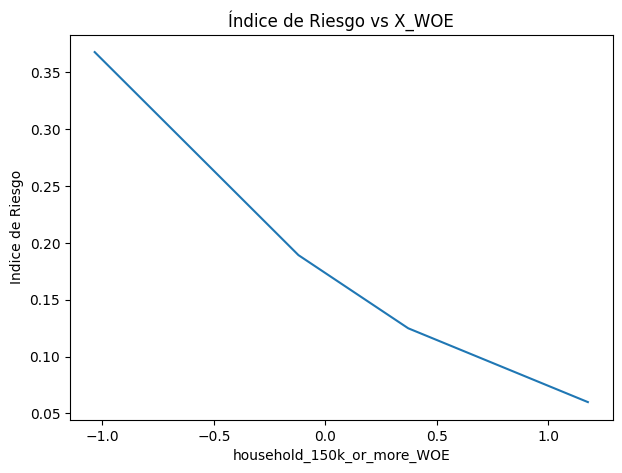

<Figure size 700x500 with 0 Axes>

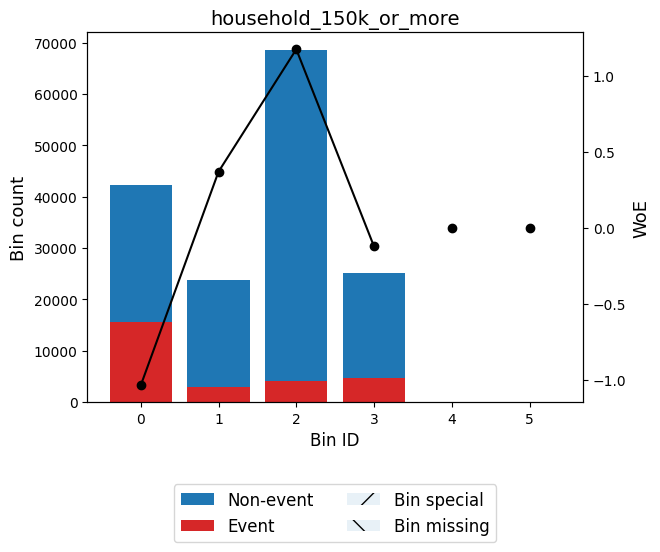

In [31]:
# Crear el primer gráfico por separado
plt.figure(figsize=(7, 5))
plt.plot(pd.crosstab(X_train[new_variable_name].values, y_train, normalize=0).iloc[:,1])
plt.xlabel(new_variable_name)
plt.ylabel("Indice de Riesgo")
plt.title("Índice de Riesgo vs X_WOE")
plt.show()

# Crear el segundo gráfico por separado
plt.figure(figsize=(7, 5))
binning_table.plot(metric="woe")

### Población de raza blanca

In [32]:
variable = 'white_population'

optb, binning_table = optimal_binning(X_train, y_train, variable)
binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.04)",10351,0.064827,7598,2753,0.265965,-0.56096,0.024236,0.002990
1,"[0.04, 0.12)",35979,0.225334,27685,8294,0.230523,-0.370795,0.034827,0.004329
2,"[0.12, 0.39)",51508,0.322590,44045,7463,0.144890,0.199101,0.011965,0.001493
3,"[0.39, 0.55)",27539,0.172474,26081,1458,0.052943,1.307988,0.188120,0.021970
4,"[0.55, inf)",34293,0.214774,26903,7390,0.215496,-0.284044,0.018972,0.002364
5,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
6,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,159670,1.000000,132312,27358,0.171341,,0.278120,0.033146


In [33]:
# Transformación WOE en el conjunto train
new_variable_name = f"{variable}_WOE"
X_train[new_variable_name] = optb.transform(X_train[variable].values, metric="woe")

# Transformación WOE en el conjunto test
new_variable_name = f"{variable}_WOE"
X_test[new_variable_name] = optb.transform(X_test[variable].values, metric="woe")

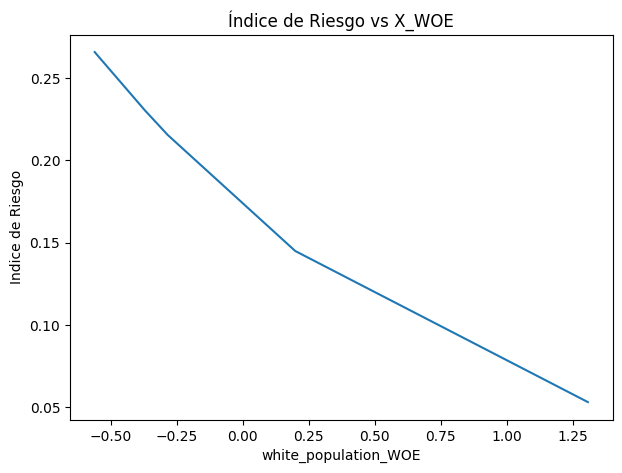

<Figure size 700x500 with 0 Axes>

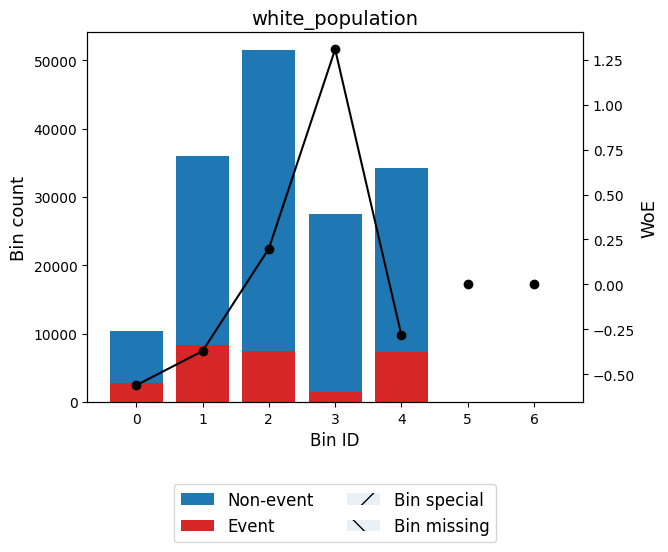

In [34]:
# Crear el primer gráfico por separado
plt.figure(figsize=(7, 5))
plt.plot(pd.crosstab(X_train[new_variable_name].values, y_train, normalize=0).iloc[:,1])
plt.xlabel(new_variable_name)
plt.ylabel("Indice de Riesgo")
plt.title("Índice de Riesgo vs X_WOE")
plt.show()

# Crear el segundo gráfico por separado
plt.figure(figsize=(7, 5))
binning_table.plot(metric="woe")

### Población de otras etnias

In [35]:
variable = 'non_white_population'

optb, binning_table = optimal_binning(X_train, y_train, variable)
binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.27)",14479,0.090681,11197,3282,0.226673,-0.348961,0.012332,0.001534
1,"[0.27, 0.46)",30470,0.190831,24904,5566,0.182671,-0.077802,0.001185,0.000148
2,"[0.46, 0.77)",43996,0.275543,36533,7463,0.169629,0.012105,0.000040,0.000005
3,"[0.77, 0.91)",35643,0.223229,32710,2933,0.082288,0.835501,0.116979,0.014211
4,"[0.91, 0.97)",23671,0.148250,20918,2753,0.116303,0.451765,0.025962,0.003218
5,"[0.97, inf)",11411,0.071466,6050,5361,0.469810,-1.455246,0.218625,0.025146
6,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
7,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,159670,1.000000,132312,27358,0.171341,,0.375122,0.044262


In [36]:
# Transformación WOE en el conjunto train
new_variable_name = f"{variable}_WOE"
X_train[new_variable_name] = optb.transform(X_train[variable].values, metric="woe")

# Transformación WOE en el conjunto test
new_variable_name = f"{variable}_WOE"
X_test[new_variable_name] = optb.transform(X_test[variable].values, metric="woe")

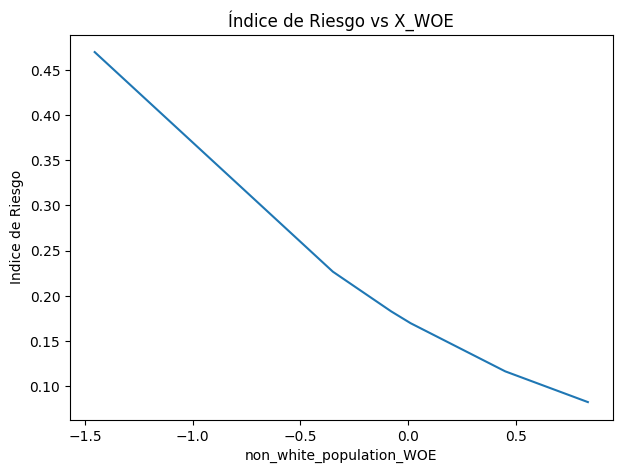

<Figure size 700x500 with 0 Axes>

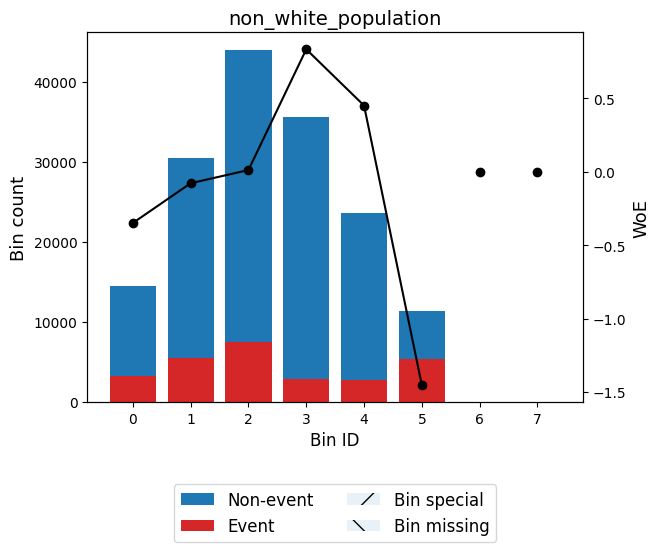

In [37]:
# Crear el primer gráfico por separado
plt.figure(figsize=(7, 5))
plt.plot(pd.crosstab(X_train[new_variable_name].values, y_train, normalize=0).iloc[:,1])
plt.xlabel(new_variable_name)
plt.ylabel("Indice de Riesgo")
plt.title("Índice de Riesgo vs X_WOE")
plt.show()

# Crear el segundo gráfico por separado
plt.figure(figsize=(7, 5))
binning_table.plot(metric="woe")

### Risk Score Lag

In [38]:
variable = 'risk_score_lag'

optb, binning_table = optimal_binning(X_train, y_train, variable)
binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.32)",73574,0.460788,70641,2933,0.039865,1.605431,0.685020,0.077474
1,"[0.32, 0.40)",74208,0.464759,57173,17035,0.229557,-0.365342,0.069620,0.008654
2,"[0.40, inf)",11888,0.074454,4498,7390,0.621635,-2.072649,0.489408,0.052144
3,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
4,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,159670,1.000000,132312,27358,0.171341,,1.244048,0.138273


In [39]:
# Transformación WOE en el conjunto train
new_variable_name = f"{variable}_WOE"
X_train[new_variable_name] = optb.transform(X_train[variable].values, metric="woe")

# Transformación WOE en el conjunto test
new_variable_name = f"{variable}_WOE"
X_test[new_variable_name] = optb.transform(X_test[variable].values, metric="woe")

### labels

In [40]:
variable = 'labels'

optb = OptimalBinning(name=variable, dtype="categorical", solver="cp")
optb.fit(X_train[variable], y_train)

binning_table = optb.binning_table
binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"[HL, LH, LL, Non-Significant]",97176,0.608605,94243,2933,0.030182,1.893697,1.145820,0.125053
1,[HH],62494,0.391395,38069,24425,0.390838,-1.132361,0.685158,0.081344
2,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
3,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,159670,1.000000,132312,27358,0.171341,,1.830978,0.206396


In [41]:
# Transformación WOE en el conjunto train
new_variable_name = f"{variable}_WOE"
X_train[new_variable_name] = optb.transform(X_train[variable].values, metric="woe")

# Transformación WOE en el conjunto test
new_variable_name = f"{variable}_WOE"
X_test[new_variable_name] = optb.transform(X_test[variable].values, metric="woe")

# Modelos de Clasificación

In [109]:
# Definimos la variable objetivo
target = "risk_level"

# Definimos las features (flexible para iterar)
features = [
    "lon", "lat",
    # 'time_of_day_WOE',         
    # "GiniIndex_WOE",
    # 'hour_sin','hour_cos',
    # 'dc_dist',
    'risk_score_lag_WOE',
    'mean_income_WOE',
    # 'non_white_population_WOE', # incluir
    # 'white_population_WOE',
    # 'household_25k_or_less_WOE', 
    'household_150k_or_more_WOE', 
    # "sig", # incluir
    "labels_WOE"        
]

X_train_model = X_train[features].copy()

# Aseguramos que el tipo de dato se cumpla
num_features = X_train_model.select_dtypes(include=["int64", "float64", "int32"]).columns.tolist()
cat_features = X_train_model.select_dtypes(include=["object", "bool"]).columns.tolist()

# Identificar variables WOE
woe_features = [col for col in X_train_model.columns if "_WOE" in col]
# Detectar variables binarias tipo bandera (como sig) → tratarlas como categóricas
binary_features = [col for col in num_features if X_train_model[col].nunique() == 2 and col not in woe_features]
# Aseguramos que no se procesen como numéricas estándar
num_features = [col for col in num_features if col not in woe_features + binary_features]
cat_features = cat_features + binary_features

print("Numéricas (escaladas):", num_features)
print("Categóricas (one-hot):", cat_features)
print("WOE (sin transformar):", woe_features)

Numéricas (escaladas): ['lon', 'lat']
Categóricas (one-hot): []
WOE (sin transformar): ['risk_score_lag_WOE', 'mean_income_WOE', 'household_150k_or_more_WOE', 'labels_WOE']


In [110]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),   # Estandarizar numéricas
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),  # One-hot en categóricas
        ("woe", "passthrough", woe_features)
    ]
)

### Random Forest

In [111]:
rf_model = RandomForestClassifier(
    n_estimators=200, 
    random_state=42, 
    # class_weight="balanced_subsample",   # útil si hay desbalance
    n_jobs=-1
)

In [112]:
# Construir pipeline con SMOTE + preprocesador + modelo
clf = ImbPipeline(steps=[
    ("preprocessor", preprocessor),   # encoding y escalado
    # ("smote", SMOTE(random_state=42)), # oversampling solo en train
    ("smote", SMOTE(sampling_strategy=0.5, random_state=42)),
    ("model", rf_model)
])

# rf_model = RandomForestClassifier(
#     n_estimators=100,
#     max_depth=8,           # ← CRÍTICO: limitar profundidad
#     min_samples_split=15,   # ← Más muestras para hacer split
#     min_samples_leaf=10,     # ← Más muestras en hojas
#     max_features=0.6,    # ← Limitar features por árbol
#     random_state=42,
#     n_jobs=-1
# )

In [89]:
# === VALIDACIÓN CRUZADA ESTRATIFICADA (OPCIÓN 3) ===
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Definir métricas importantes para tu contexto de seguridad
scoring = {
    'accuracy': 'accuracy',
    'precision_macro': 'precision_macro',
    'recall_macro': 'recall_macro', 
    'f1_macro': 'f1_macro',
    'recall_class_1': make_scorer(recall_score, pos_label=1),  # Crítico: no perder lugares peligrosos
    'precision_class_1': make_scorer(precision_score, pos_label=1),  # Reducir falsas alarmas
    'recall_class_0': make_scorer(recall_score, pos_label=0),  # Detectar lugares seguros
    'precision_class_0': make_scorer(precision_score, pos_label=0)   # Confianza en "seguro"
}

print("🔄 Ejecutando Validación Cruzada Estratificada...")
print("   Pipeline: Preprocessor → SMOTE → Random Forest")
print("   Folds: 5 estratificados\n")

# Ejecutar validación cruzada
cv_results = cross_validate(
    clf, X_train_model, y_train, 
    cv=cv, 
    scoring=scoring, 
    return_train_score=True,
    n_jobs=-1,
    verbose=1
)

# === ANÁLISIS DE RESULTADOS ===
print("="*60)
print("📊 RESULTADOS DE VALIDACIÓN CRUZADA")
print("="*60)

🔄 Ejecutando Validación Cruzada Estratificada...
   Pipeline: Preprocessor → SMOTE → Random Forest
   Folds: 5 estratificados



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:  1.2min remaining:  1.9min
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  1.2min finished


📊 RESULTADOS DE VALIDACIÓN CRUZADA


In [93]:
for metric_name in scoring.keys():
    test_scores = cv_results[f'test_{metric_name}']
    train_scores = cv_results[f'train_{metric_name}']
    
    print(f"\n{metric_name.upper().replace('_', ' ')}:")
    print(f"  Test:  {test_scores.mean():.4f} (±{test_scores.std():.4f})")
    print(f"  Train: {train_scores.mean():.4f} (±{train_scores.std():.4f})")
    
    # # Detectar overfitting
    # gap = train_scores.mean() - test_scores.mean()
    # if gap > 0.05:
    #     print(f"  ⚠️  Posible overfitting (gap: {gap:.3f})")
    # elif gap > 0.02:
    #     print(f"  ⚡ Gap moderado (gap: {gap:.3f})")
    # else:
    #     print(f"  ✅ Gap saludable (gap: {gap:.3f})")



ACCURACY:
  Test:  0.8908 (±0.0008)
  Train: 0.9610 (±0.0003)

PRECISION MACRO:
  Test:  0.8020 (±0.0013)
  Train: 0.9169 (±0.0005)

RECALL MACRO:
  Test:  0.8478 (±0.0022)
  Train: 0.9547 (±0.0009)

F1 MACRO:
  Test:  0.8216 (±0.0014)
  Train: 0.9343 (±0.0005)

RECALL CLASS 1:
  Test:  0.7823 (±0.0049)
  Train: 0.9452 (±0.0019)

PRECISION CLASS 1:
  Test:  0.6509 (±0.0023)
  Train: 0.8453 (±0.0012)

RECALL CLASS 0:
  Test:  0.9133 (±0.0010)
  Train: 0.9642 (±0.0004)

PRECISION CLASS 0:
  Test:  0.9530 (±0.0010)
  Train: 0.9884 (±0.0004)


In [90]:
# === ANÁLISIS ESPECÍFICO PARA SEGURIDAD ===
print("\n" + "="*60)
print("🛡️  ANÁLISIS DE SEGURIDAD")
print("="*60)

recall_danger = cv_results['test_recall_class_1']
precision_danger = cv_results['test_precision_class_1']
recall_safe = cv_results['test_recall_class_0']

print(f"\n🚨 LUGARES PELIGROSOS (Clase 1):")
print(f"   Recall: {recall_danger.mean():.1%} ± {recall_danger.std():.1%}")
print(f"   → Detecta {recall_danger.mean():.1%} de lugares peligrosos")
print(f"   → Se pierden {(1-recall_danger.mean()):.1%} de lugares peligrosos")

print(f"\n   Precision: {precision_danger.mean():.1%} ± {precision_danger.std():.1%}")
print(f"   → {precision_danger.mean():.1%} de alertas son reales")
print(f"   → {(1-precision_danger.mean()):.1%} son falsas alarmas")

print(f"\n🛡️ LUGARES SEGUROS (Clase 0):")
print(f"   Recall: {recall_safe.mean():.1%} ± {recall_safe.std():.1%}")
print(f"   → Identifica correctamente {recall_safe.mean():.1%} de lugares seguros")

# === ESTABILIDAD DEL MODELO ===
print(f"\n📈 ESTABILIDAD:")
recall_danger_std = recall_danger.std()
if recall_danger_std < 0.02:
    print(f"   ✅ Muy estable (std recall peligrosos: {recall_danger_std:.3f})")
elif recall_danger_std < 0.05:
    print(f"   ⚡ Moderadamente estable (std: {recall_danger_std:.3f})")
else:
    print(f"   ⚠️  Inestable entre folds (std: {recall_danger_std:.3f})")



🛡️  ANÁLISIS DE SEGURIDAD

🚨 LUGARES PELIGROSOS (Clase 1):
   Recall: 78.2% ± 0.5%
   → Detecta 78.2% de lugares peligrosos
   → Se pierden 21.8% de lugares peligrosos

   Precision: 65.1% ± 0.2%
   → 65.1% de alertas son reales
   → 34.9% son falsas alarmas

🛡️ LUGARES SEGUROS (Clase 0):
   Recall: 91.3% ± 0.1%
   → Identifica correctamente 91.3% de lugares seguros

📈 ESTABILIDAD:
   ✅ Muy estable (std recall peligrosos: 0.005)


In [113]:
# === ENTRENAMIENTO FINAL ===
print("\n" + "="*60)
print("🎯 ENTRENANDO MODELO FINAL")
print("="*60)

print("Entrenando pipeline completo en todos los datos de train...")
clf.fit(X_train_model, y_train)

# Predicciones en test set
print("Realizando predicciones en test set...")
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

# Reporte final
print("\n📋 REPORTE FINAL EN TEST SET:")
print(classification_report(y_test, y_pred, 
                          target_names=['Seguro (0)', 'Peligroso (1)']))

# === RECOMENDACIONES FINALES ===
print("\n" + "="*60)
print("💡 RECOMENDACIONES")
print("="*60)

avg_recall_danger = recall_danger.mean()
avg_precision_danger = precision_danger.mean()

if avg_recall_danger >= 0.85:
    print("✅ Excelente detección de lugares peligrosos")
elif avg_recall_danger >= 0.75:
    print("⚡ Buena detección de lugares peligrosos")
else:
    print("⚠️  Considera ajustar threshold o hiperparámetros")

if avg_precision_danger >= 0.70:
    print("✅ Falsas alarmas bajo control")
elif avg_precision_danger >= 0.50:
    print("⚡ Falsas alarmas moderadas - evalúa si es aceptable")
else:
    print("⚠️  Muchas falsas alarmas - considera ajustar threshold")

print(f"\n🎯 Modelo entrenado y listo para usar!")
print(f"   - Variable y_pred: Predicciones binarias")
print(f"   - Variable y_prob: Probabilidades de peligro")


🎯 ENTRENANDO MODELO FINAL
Entrenando pipeline completo en todos los datos de train...
Realizando predicciones en test set...

📋 REPORTE FINAL EN TEST SET:
               precision    recall  f1-score   support

   Seguro (0)       0.95      0.90      0.92     49088
Peligroso (1)       0.59      0.78      0.67      9517

     accuracy                           0.88     58605
    macro avg       0.77      0.84      0.80     58605
 weighted avg       0.90      0.88      0.88     58605


💡 RECOMENDACIONES
⚡ Buena detección de lugares peligrosos
⚡ Falsas alarmas moderadas - evalúa si es aceptable

🎯 Modelo entrenado y listo para usar!
   - Variable y_pred: Predicciones binarias
   - Variable y_prob: Probabilidades de peligro


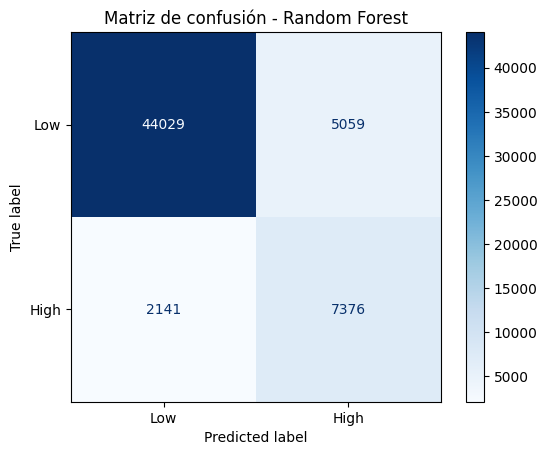

In [114]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred, labels=[0,1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Low", "High"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de confusión - Random Forest")
plt.show()


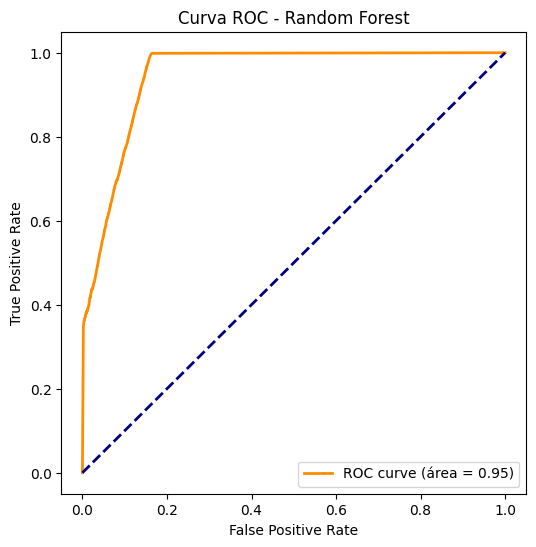

In [85]:
# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (área = {roc_auc:.2f})")
plt.plot([0,1], [0,1], color="navy", lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Random Forest")
plt.legend(loc="lower right")
plt.show()

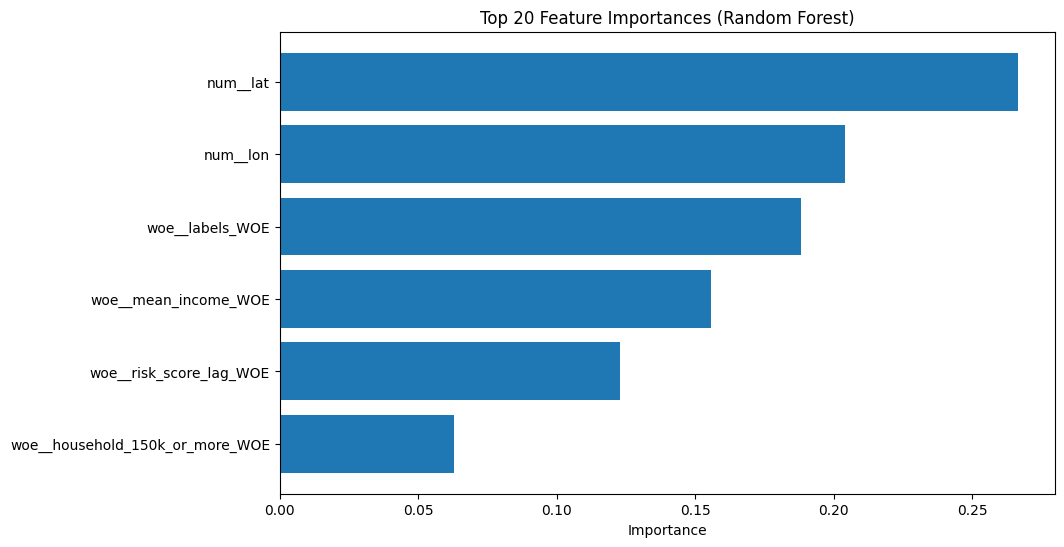

In [115]:
# 1. Recuperar el modelo entrenado
rf_model = clf.named_steps["model"]

# 2. Recuperar nombres de columnas después del preprocesador
#    - numéricas pasan directas
#    - categóricas se expanden con OneHotEncoder
feature_names = clf.named_steps["preprocessor"].get_feature_names_out()

# 3. Importancias desde el modelo
importances = rf_model.feature_importances_

# 4. Crear DataFrame ordenado
feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

# 5. Graficar
plt.figure(figsize=(10, 6))
plt.barh(feat_imp["feature"][:20], feat_imp["importance"][:20])  # Top 20
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.show()

#### Grid Search

In [ ]:
from sklearn.model_selection import GridSearchCV

# Definir grilla pequeña pero informativa
param_grid = {
    "model__n_estimators": [100, 200],            # número de árboles
    "model__max_depth": [None, 10, 20],           # profundidad máxima
    "model__min_samples_split": [2, 10],          # min muestras para split
    "model__min_samples_leaf": [1, 5],            # min muestras en hoja
    "model__max_features": ["sqrt", "log2"]       # número de features usadas en cada split
}

# GridSearchCV sobre tu pipeline
grid_search = GridSearchCV(
    estimator=clf,
    param_grid=param_grid,
    cv=3,                        # validación cruzada con 3 folds
    scoring="f1_macro",          # optimizamos f1 macro (balancea las clases)
    n_jobs=-1,                   # usa todos los cores disponibles
    verbose=2
)

print("🚀 Ejecutando GridSearchCV...")
grid_search.fit(X_train_model, y_train)

# Resultados
print("\n✅ Mejor combinación de hiperparámetros:")
print(grid_search.best_params_)
print(f"Mejor score CV: {grid_search.best_score_:.4f}")

# Reentrenar modelo final con los mejores parámetros encontrados
best_model = grid_search.best_estimator_

print("\n🎯 Entrenando modelo final con los mejores parámetros en todo el train...")
best_model.fit(X_train_model, y_train)

# Evaluación en test
y_pred = best_model.predict(X_test)
print("\n📋 REPORTE FINAL EN TEST SET:")
print(classification_report(y_test, y_pred, 
                            target_names=['Seguro (0)', 'Peligroso (1)']))


In [117]:
from sklearn.model_selection import GridSearchCV

# Definir un grid pequeño y enfocado
param_grid = {
    "model__max_depth": [10, 15, None],         # limitar o no la profundidad
    "model__min_samples_leaf": [1, 5, 10],      # suavizar hojas
    "model__max_features": ["sqrt", "log2"],    # aleatoriedad en splits
    "model__n_estimators": [100, 200]           # mantener bajo para eficiencia
}

# Definir scorer para precisión de la clase positiva (1)
precision_minority = make_scorer(precision_score, pos_label=1)

# GridSearch con validación cruzada estratificada
grid_search = GridSearchCV(
    clf, 
    param_grid=param_grid, 
    cv=3,                         # 3 folds para no sobrecargar
    scoring=precision_minority,           # balancear ambas clases
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train_model, y_train)

print("Mejores parámetros:", grid_search.best_params_)
print("Mejor score:", grid_search.best_score_)

# Reentrenar modelo final con los mejores parámetros encontrados
best_model = grid_search.best_estimator_

print("\n🎯 Entrenando modelo final con los mejores parámetros en todo el train...")
best_model.fit(X_train_model, y_train)

# Evaluación en test
y_pred = best_model.predict(X_test)
print("\n📋 REPORTE FINAL EN TEST SET:")
print(classification_report(y_test, y_pred, 
                            target_names=['Seguro (0)', 'Peligroso (1)']))

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Mejores parámetros: {'model__max_depth': None, 'model__max_features': 'log2', 'model__min_samples_leaf': 1, 'model__n_estimators': 100}
Mejor score: 0.6408339870523494

🎯 Entrenando modelo final con los mejores parámetros en todo el train...

📋 REPORTE FINAL EN TEST SET:
               precision    recall  f1-score   support

   Seguro (0)       0.95      0.90      0.92     49088
Peligroso (1)       0.59      0.77      0.67      9517

     accuracy                           0.88     58605
    macro avg       0.77      0.83      0.80     58605
 weighted avg       0.89      0.88      0.88     58605

